** Define the backtest window and compute portfolio return series**

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join("..", "src")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import fetch_data
from data_cleaning import handle_missing_values

data = handle_missing_values(fetch_data())

prices = pd.DataFrame({
    "TSLA": data["TSLA"]["Close"],
    "BND": data["BND"]["Close"],
    "SPY": data["SPY"]["Close"],
}).dropna()

daily_returns = prices.pct_change().dropna()

# Backtest window: last ~1.5 years (matches Task 2/3's test period)
BACKTEST_START = "2025-01-01"
backtest_returns = daily_returns[daily_returns.index >= BACKTEST_START]

print(f"Backtest window: {backtest_returns.index.min().date()} to {backtest_returns.index.max().date()}")
print(f"Number of trading days: {len(backtest_returns)}")

[*********************100%***********************]  3 of 3 completed

Backtest window: 2025-01-02 to 2026-06-29
Number of trading days: 372


**Define strategy and benchmark weights, simulate both**

In [4]:
TRADING_DAYS = 252

# Task 4's recommended portfolio (Max Sharpe)
strategy_weights = {"TSLA": 0.0, "BND": 0.0, "SPY": 1.0}

# Benchmark: static 60% SPY / 40% BND
benchmark_weights = {"TSLA": 0.0, "BND": 0.40, "SPY": 0.60}

def portfolio_daily_returns(returns_df, weights: dict, rebalance="none"):
    """
    Compute a portfolio's daily return series given fixed target weights.
    rebalance="monthly" rebalances back to target weights at the start of each month.
    rebalance="none" holds initial dollar allocations and lets them drift.
    """
    w = pd.Series(weights)
    if rebalance == "none":
        # Weighted sum of daily returns each day (equivalent to holding fixed weights, no drift correction)
        return (returns_df * w).sum(axis=1)
    elif rebalance == "monthly":
        port_returns = []
        current_weights = w.copy()
        current_month = None
        for date, row in returns_df.iterrows():
            if current_month != date.month:
                current_weights = w.copy()  # reset to target at start of each new month
                current_month = date.month
            daily_ret = (row * current_weights).sum()
            port_returns.append(daily_ret)
        return pd.Series(port_returns, index=returns_df.index)
    else:
        raise ValueError("rebalance must be 'none' or 'monthly'")

strategy_returns = portfolio_daily_returns(backtest_returns, strategy_weights, rebalance="none")
benchmark_returns = portfolio_daily_returns(backtest_returns, benchmark_weights, rebalance="monthly")

print(f"Strategy daily returns — mean: {strategy_returns.mean()*100:.4f}%, std: {strategy_returns.std()*100:.4f}%")
print(f"Benchmark daily returns — mean: {benchmark_returns.mean()*100:.4f}%, std: {benchmark_returns.std()*100:.4f}%")

Strategy daily returns — mean: 0.0739%, std: 1.1285%
Benchmark daily returns — mean: 0.0527%, std: 0.7049%


**Visualize and Identify Key Portfolios
**

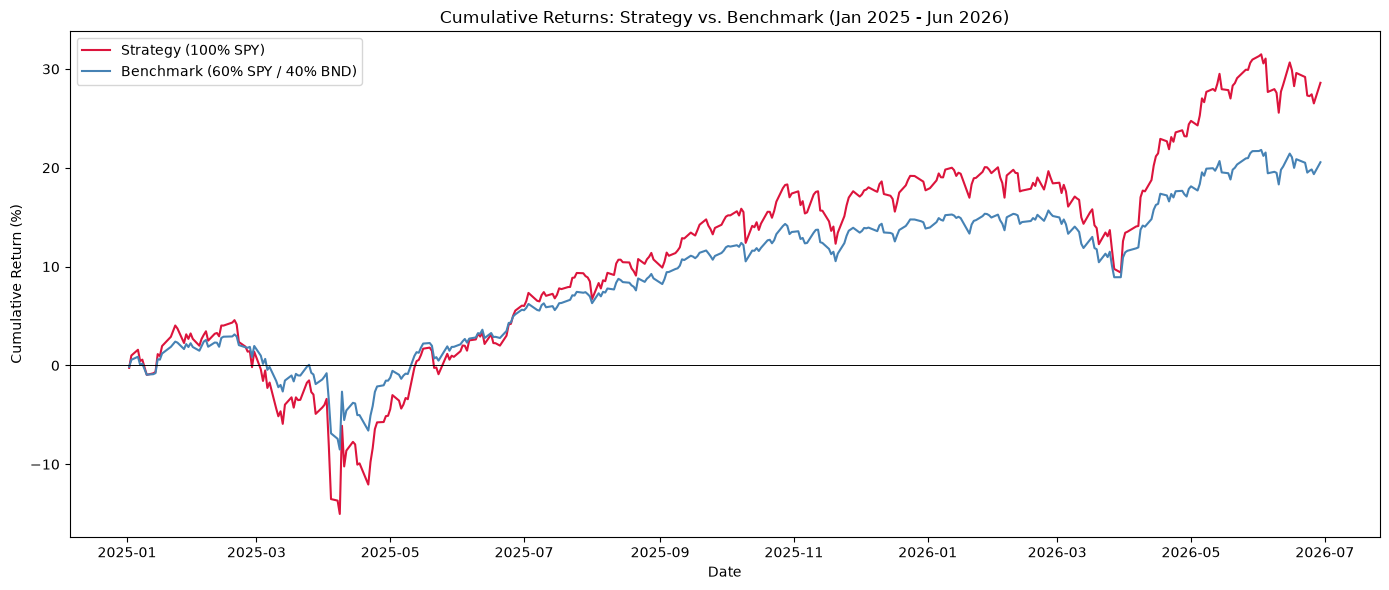

In [5]:
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_benchmark = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cumulative_strategy.index, (cumulative_strategy - 1) * 100, label="Strategy (100% SPY)", color="crimson", linewidth=1.5)
plt.plot(cumulative_benchmark.index, (cumulative_benchmark - 1) * 100, label="Benchmark (60% SPY / 40% BND)", color="steelblue", linewidth=1.5)
plt.axhline(0, color="black", linewidth=0.7)
plt.title("Cumulative Returns: Strategy vs. Benchmark (Jan 2025 - Jun 2026)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
TRADING_DAYS = 252
RISK_FREE_RATE = 0.02

def compute_metrics(returns, cumulative, label):
    total_return = cumulative.iloc[-1] - 1
    n_days = len(returns)
    annualized_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1

    daily_std = returns.std()
    annualized_vol = daily_std * np.sqrt(TRADING_DAYS)

    daily_rf = RISK_FREE_RATE / TRADING_DAYS
    sharpe = ((returns.mean() - daily_rf) / daily_std) * np.sqrt(TRADING_DAYS)

    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Portfolio": label,
        "Total Return": f"{total_return*100:.2f}%",
        "Annualized Return": f"{annualized_return*100:.2f}%",
        "Annualized Volatility": f"{annualized_vol*100:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_drawdown*100:.2f}%",
    }

strategy_metrics = compute_metrics(strategy_returns, cumulative_strategy, "Strategy (100% SPY)")
benchmark_metrics = compute_metrics(benchmark_returns, cumulative_benchmark, "Benchmark (60/40)")

results_df = pd.DataFrame([strategy_metrics, benchmark_metrics]).set_index("Portfolio")
print(results_df.to_string())

                    Total Return Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
Portfolio                                                                                         
Strategy (100% SPY)       28.60%            18.58%                17.91%         0.93      -18.76%
Benchmark (60/40)         20.56%            13.50%                11.19%         1.01      -11.29%


## Backtest Results and Conclusion

| Metric | Strategy (100% SPY) | Benchmark (60% SPY / 40% BND) |
|--------|---------------------|-------------------------------|
| Total Return | 28.60% | 20.56% |
| Annualized Return | 18.58% | 13.50% |
| Annualized Volatility | 17.91% | 11.19% |
| Sharpe Ratio | 0.93 | 1.01 |
| Max Drawdown | -18.76% | -11.29% |

**Did the strategy outperform the benchmark?**
On raw returns, yes: the Task 4 recommended strategy (100% SPY) delivered a
total return roughly 8 percentage points higher than the static 60/40
benchmark over the 18-month backtest window. However, on a risk-adjusted
basis, the benchmark narrowly outperformed the strategy (Sharpe Ratio 1.01
vs. 0.93), and did so while experiencing a substantially smaller maximum
drawdown (-11.29% vs. -18.76%). The strategy's outperformance in absolute
terms is therefore attributable to taking on meaningfully more risk, not to
superior risk-adjusted skill.

**What does this suggest about the model-driven approach?**
This result is a direct, traceable consequence of the Task 3 forecast: since
ARIMA(0,1,0) projected an essentially flat return for TSLA, the Task 4
optimizer allocated 0% to TSLA and 100% to SPY, effectively collapsing the
"optimized" strategy into a concentrated single-asset equity bet rather
than a genuinely diversified allocation. The backtest suggests that, under
this specific forecast, the model-driven approach did not produce a
better-diversified or more risk-efficient portfolio than a simple static
benchmark — it produced a more aggressive one. This is a valuable, honest
finding: it shows the pipeline is highly sensitive to the quality and
nature of the input forecast, and that a flat (uninformative) forecast for
one asset effectively removes it from consideration, regardless of that
asset's historical appeal.

**Limitations of this backtest**
- The backtest window (Jan 2025 - Jun 2026) is relatively short (~18 months)
  and includes at least one major systemic shock (the April 2025 tariff
  policy volatility), which may not be representative of typical market
  conditions going forward.
- The strategy was tested with a single, static allocation (100% SPY) with
  no rebalancing, since there was only one asset to hold; a more dynamic
  strategy that re-optimizes periodically as new forecasts become available
  was not tested here.
- The result is entirely contingent on Task 3's specific ARIMA forecast for
  TSLA. A different model or a forecast incorporating additional
  information (e.g., macro indicators, sentiment data) could produce a
  materially different — and potentially better-diversified — optimal
  portfolio.
- Transaction costs, taxes, and slippage were not modeled; both portfolios
  assume frictionless trading, which would modestly reduce real-world
  returns for both, though more so for any strategy requiring rebalancing.